# UGANDA FOOD PRICE ANALYSIS: INFLATION, REGIONAL TRENDS, AND COMMODITY DYNAMICS

**Project Overview**

This project analyzes food price trends in Uganda using data from the World Food Programme (WFP) Price Database. The analysis explores how food prices vary across commodities, categories, regions, and time, with a particular focus on inflation trends, staple food affordability, market volatility, and regional disparities. Through data visualization and statistical analysis, the project aims to provide insights into the economic and geographic factors influencing food prices and food accessibility in Uganda.

**Project Objectives**



*   Analyze food price trends over time to identify inflation patterns.
*   Compare prices across different food commodities and categories.
*   Investigate regional variations in food prices across Uganda.
*   Examine trends in staple and fresh food categories over time.
*   Apply regression analysis to identify factors associated with food price changes.
*   Generate data-driven insights that can support discussions on food affordability and market dynamics in Uganda.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# DESCRIPTIVE DATA ANALYSIS

In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/data-projects/wfp_food_prices_uga.csv')

df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,1/15/2006,Busia,Samia-bugwe,Busia,2665,0.47,34.09,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,298.40,0.17
1,1/15/2006,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,345.42,0.20
2,1/15/2006,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Rice,52,KG,actual,Wholesale,UGX,1013.40,0.58
3,2/15/2006,Busia,Samia-bugwe,Busia,2665,0.47,34.09,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,296.59,0.17
4,2/15/2006,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,347.23,0.20


In [6]:
df.describe(include = 'all')

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
count,28465,28465,28465,28465,28465.000000,28465.000000,28465.000000,28465,28465,28465.000000,28465,28465,28465,28465,28465.000000,28465.000000
unique,243,37,40,43,NaN,NaN,NaN,8,38,NaN,5,1,2,1,NaN,NaN
top,12/15/2024,Arua,Bukanga,Owino,NaN,NaN,NaN,cereals and tubers,Maize flour,NaN,KG,actual,Retail,UGX,NaN,NaN
freq,546,2222,2185,2044,NaN,NaN,NaN,13755,2894,NaN,20733,28465,27237,28465,NaN,NaN
mean,NaN,NaN,NaN,NaN,4307.902231,1.624548,32.128051,NaN,NaN,318.400949,NaN,NaN,NaN,NaN,3005.414041,0.836689
std,NaN,NaN,NaN,NaN,2775.677634,1.442432,1.251629,NaN,NaN,367.229267,NaN,NaN,NaN,NaN,3310.931370,0.897471
min,NaN,NaN,NaN,NaN,257.000000,-1.250000,29.990000,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,2.000000,0.000570
25%,NaN,NaN,NaN,NaN,264.000000,0.360000,31.030000,NaN,NaN,67.000000,NaN,NaN,NaN,NaN,1167.000000,0.340000
50%,NaN,NaN,NaN,NaN,6405.000000,1.690000,31.780000,NaN,NaN,76.000000,NaN,NaN,NaN,NaN,2000.000000,0.570000
75%,NaN,NaN,NaN,NaN,6411.000000,3.230000,32.910000,NaN,NaN,540.000000,NaN,NaN,NaN,NaN,3500.000000,0.950000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28465 entries, 0 to 28464
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          28465 non-null  object 
 1   admin1        28465 non-null  object 
 2   admin2        28465 non-null  object 
 3   market        28465 non-null  object 
 4   market_id     28465 non-null  int64  
 5   latitude      28465 non-null  float64
 6   longitude     28465 non-null  float64
 7   category      28465 non-null  object 
 8   commodity     28465 non-null  object 
 9   commodity_id  28465 non-null  int64  
 10  unit          28465 non-null  object 
 11  priceflag     28465 non-null  object 
 12  pricetype     28465 non-null  object 
 13  currency      28465 non-null  object 
 14  price         28465 non-null  float64
 15  usdprice      28465 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 3.5+ MB


In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df.isnull().sum()

,0
date,0
admin1,0
admin2,0
market,0
market_id,0
latitude,0
longitude,0
category,0
commodity,0
commodity_id,0


In [9]:
#Getting an idea of the distribution across the different commodities
df['commodity'].value_counts().head(10)

,count
commodity,
Maize flour,2894
Maize (white),2719
Beans,2708
Sorghum,2489
Oil (vegetable),2344
Cassava flour,2181
Millet,1368
Leafy vegetables,752
Salt,744


In [13]:
category_commodity_table = (
    df.groupby('category')['commodity']
    .unique()
    .reset_index()
)

category_commodity_table

,category,commodity
0,cereals and tubers,"[Maize, Rice, Cassava flour, Maize flour, Maiz..."
1,"meat, fish and eggs",[Fish (dry)]
2,milk and dairy,[Milk (fresh)]
3,miscellaneous food,[Salt]
4,non-food,"[Basin, Charcoal, Exercise Book (48 pages), Fi..."
5,oil and fats,[Oil (vegetable)]
6,pulses and nuts,[Beans]
7,vegetables and fruits,"[Plantains, Leafy vegetables]"


In [14]:
df_clean = df.copy()

In [15]:
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month

Since we notice that this dataset has both food and non food items, we need to narrow down our analysis to only the food items for this study. Next, we shall remove the non food items and stay with only the food items

In [16]:
#Understanding the distribution across the different categories
df_clean['category'].value_counts()

,count
category,
cereals and tubers,13755
non-food,6816
pulses and nuts,2708
oil and fats,2344
vegetables and fruits,1103
miscellaneous food,744
milk and dairy,543
"meat, fish and eggs",452


In [17]:
#Filtering out non-food items and miscellaneous food
food_categories = [
    'cereals and tubers',
    'pulses and nuts',
    'oil and fats',
    'vegetables and fruits',
    'milk and dairy',
    'meat, fish and eggs',
    'miscellaneous food'
]

df_food = df_clean[df_clean['category'].isin(food_categories)].copy()

In [18]:
df_food['category'].value_counts()

,count
category,
cereals and tubers,13755
pulses and nuts,2708
oil and fats,2344
vegetables and fruits,1103
miscellaneous food,744
milk and dairy,543
"meat, fish and eggs",452


In [19]:
commodity_avg = df_food.groupby('commodity')['price'].mean().sort_values(ascending=False)

commodity_avg.head(10)

,price
commodity,
Fish (dry),20180.081858
Oil (vegetable),7533.519573
Millet flour,4122.949429
Beans,3150.079431
Millet,2655.953282
Rice,2433.013978
Maize flour,2382.393694
Leafy vegetables,1942.545612
Milk (fresh),1753.703499


# COMMODITY ANALYSIS

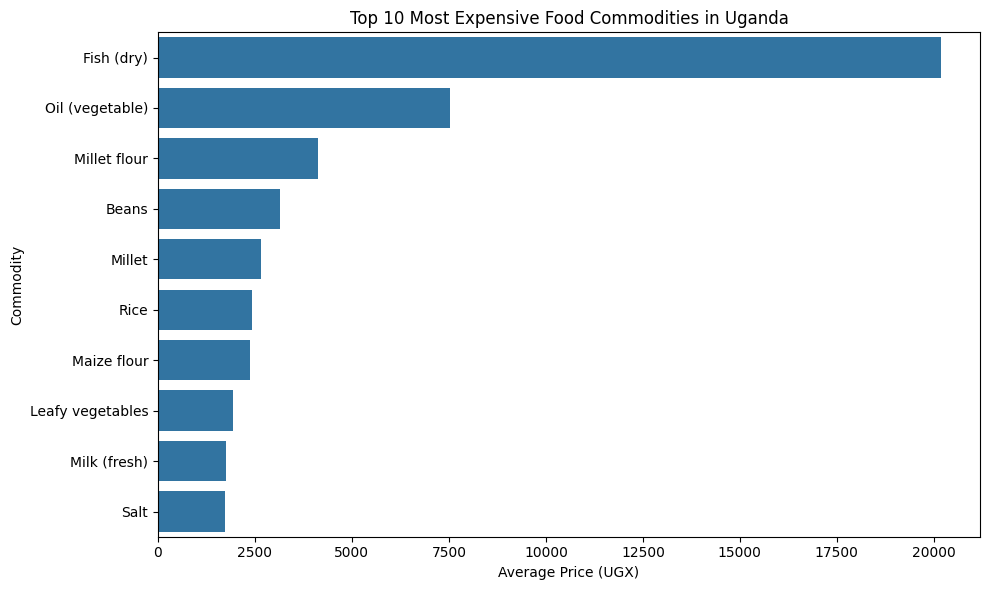

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

#Commodity level analysis
top10 = commodity_avg.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)

plt.title('Top 10 Most Expensive Food Commodities in Uganda')
plt.xlabel('Average Price (UGX)')
plt.ylabel('Commodity')

plt.tight_layout()
plt.show()

Here, we realize dry fish, vegetable oil and millet flour are the most expensive items. This aligns with expectations since these are processed food stuffs and which naturally command higher prices.
Staples like millet and beans also appear due to their importance in local diets and variability in supply. Overall, these results are expected, as essential and protein-rich foods tend to have higher average prices compared to basic staples.

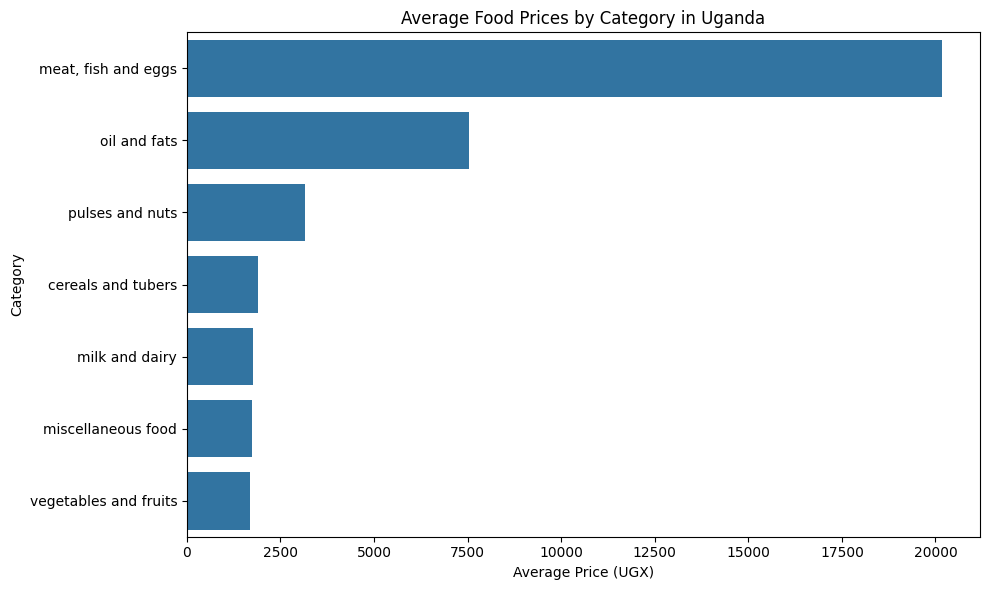

In [21]:
#Category Level Analysis
category_avg = df_food.groupby('category')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=category_avg.values, y=category_avg.index)

plt.title('Average Food Prices by Category in Uganda')
plt.xlabel('Average Price (UGX)')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

Food categories such as meat, fish, and eggs, as well as oils and fats, have the highest average prices, which is expected given their higher production, processing, and preservation costs. In contrast, categories like vegetables and fruits and staple items such as cereals tend to be more affordable, reflecting their availability and role in daily consumption. This suggests that nutrient-rich food groups may be less accessible due to higher costs, highlighting potential affordability challenges.

# TIME SERIES ANALYSIS

In [22]:
yearly_prices = df_food.groupby('year')['price'].mean()

yearly_prices

,price
year,
2006,588.895588
2007,555.889697
2008,802.865758
2009,987.800000
2010,951.757017
2011,1190.070137
2012,1360.540087
2013,1433.589916
2014,1351.101517


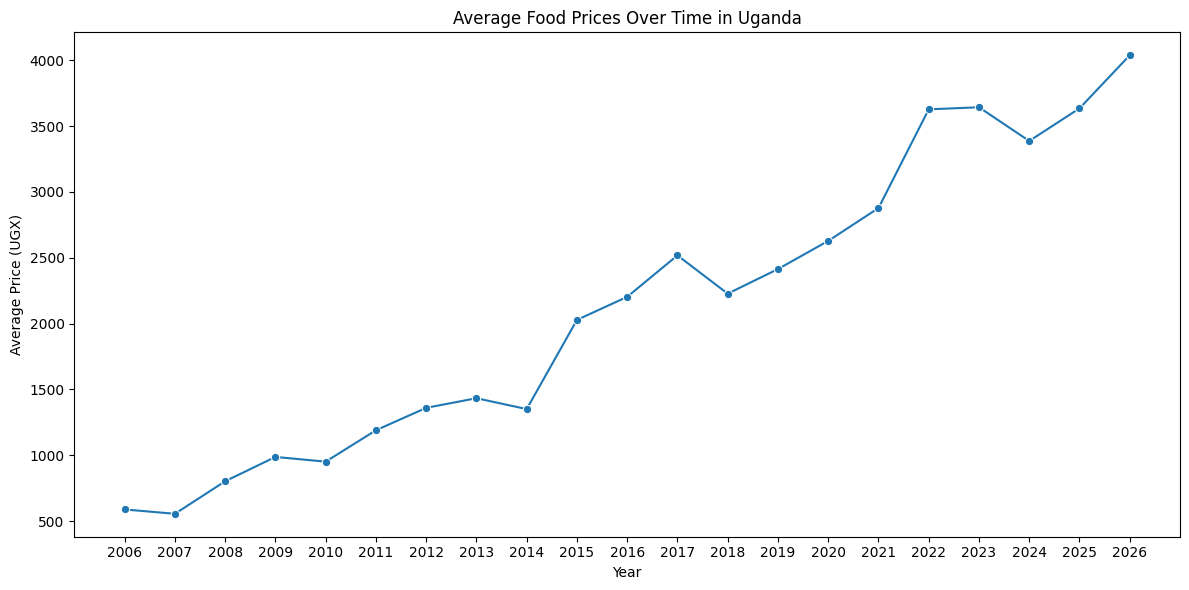

In [23]:
# Average yearly food prices
yearly_prices = df_food.groupby('year')['price'].mean().reset_index()

# Plot yearly trend
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_prices,
    x='year',
    y='price',
    marker='o'
)

plt.title('Average Food Prices Over Time in Uganda')
plt.xlabel('Year')
plt.ylabel('Average Price (UGX)')

# Force clean integer year labels
plt.xticks(yearly_prices['year'].unique())

plt.tight_layout()
plt.show()

The analysis shows a generally steady increase in food prices during the earlier years, followed by a more rapid rise in later years, suggesting increasing inflationary pressure over time. Although temporary price declines are observed around years such as 2014, 2018, and 2024, these dips are typically followed by sharp increases in subsequent years, indicating recurring market instability and continued upward pressure on food prices.

In [24]:
df_food['year'].value_counts().sort_index()

,count
year,
2006,34
2007,33
2008,66
2009,101
2010,295
2011,512
2012,576
2013,592
2014,501


This simply backs up the drops actually happened and were not as a result of incomplete data in that year.

# CATEGORY BASED TIME SERIES ANALYSIS

In [25]:
#Creating top categories
top_categories = [
    'meat, fish and eggs',
    'oil and fats',
    'pulses and nuts'
]

df_top_categories = df_food[df_food['category'].isin(top_categories)]

category_trends = df_top_categories.groupby(
    ['year', 'category']
)['price'].mean().reset_index()

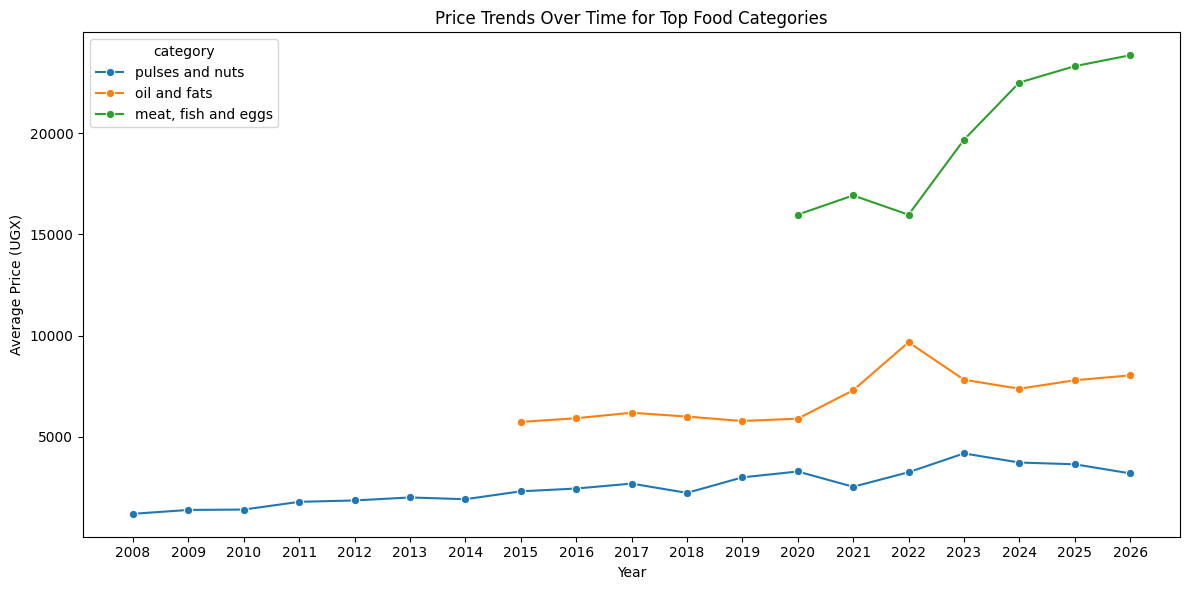

In [26]:
#Time series analysis for Top food Categories
df_food['year'] = df_food['year'].astype(int)
plt.figure(figsize=(12,6))

sns.lineplot(
    data=category_trends,
    x='year',
    y='price',
    hue='category',
    marker='o'
)

plt.title('Price Trends Over Time for Top Food Categories')
plt.xlabel('Year')
plt.ylabel('Average Price (UGX)')

plt.xticks(category_trends['year'].unique())

plt.tight_layout()
plt.show()



- Pulses and nuts (which is basically beans) show relatively stable prices, possibly because they are less dependent on complex supply chains or imports.
- Oils and fats experienced a sharp price increase between 2020 and 2022, which may be linked to COVID-19 disruptions, reduced trade activity, higher transportation costs, and global supply chain instability during and after lockdown periods.
- Meat, fish, and eggs, particularly dry fish products, showed strong price increases from 2022 to 2024, which could reflect rising production and preservation costs, increased fuel prices, and post-pandemic economic pressures affecting protein-rich food commodities more heavily.


In [27]:
Staple_and_Fresh_Food_Categories = [
    'pulses and nuts',
    'vegetables and fruits',
    'cereals and tubers'
]

Staple_and_Fresh_Food_Categories_table = (
    df_food[df_food['category'].isin(Staple_and_Fresh_Food_Categories)]
    .groupby('category')['commodity']
    .unique()
    .reset_index()
)

Staple_and_Fresh_Food_Categories_table

,category,commodity
0,cereals and tubers,"[Maize, Rice, Cassava flour, Maize flour, Maiz..."
1,pulses and nuts,[Beans]
2,vegetables and fruits,"[Plantains, Leafy vegetables]"


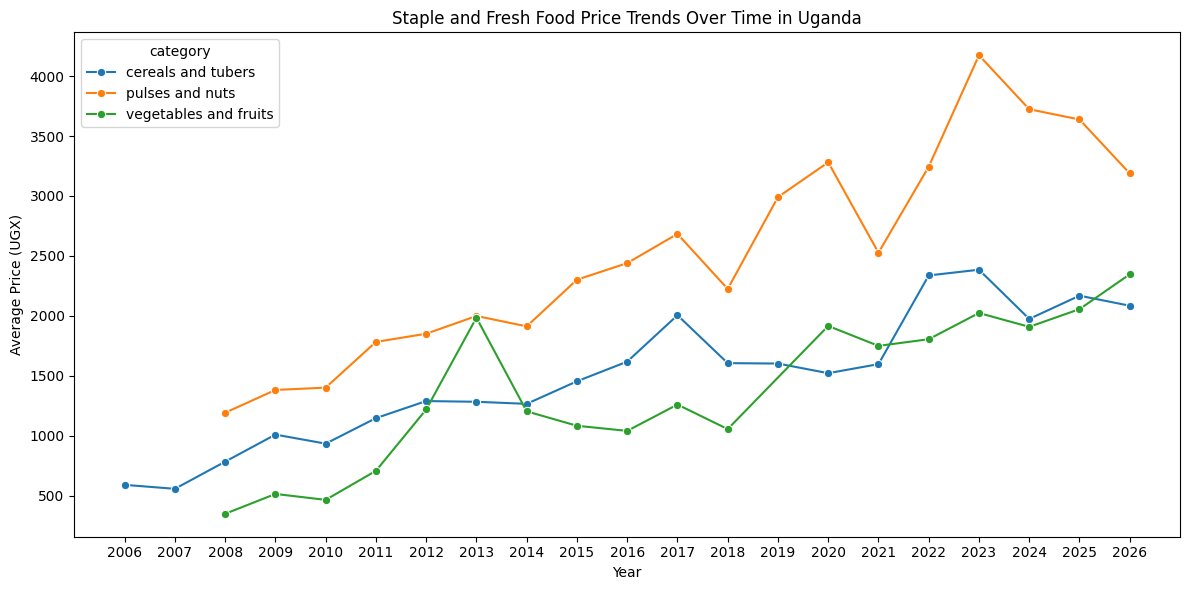

In [28]:
df_staple = df_food[df_food['category'].isin(Staple_and_Fresh_Food_Categories)].copy()
staple_trends = df_staple.groupby(['year', 'category'])['price'].mean().reset_index()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    data=staple_trends,
    x='year',
    y='price',
    hue='category',
    marker='o'
)

plt.title('Staple and Fresh Food Price Trends Over Time in Uganda')
plt.xlabel('Year')
plt.ylabel('Average Price (UGX)')

plt.xticks(staple_trends['year'].unique())

plt.tight_layout()
plt.show()

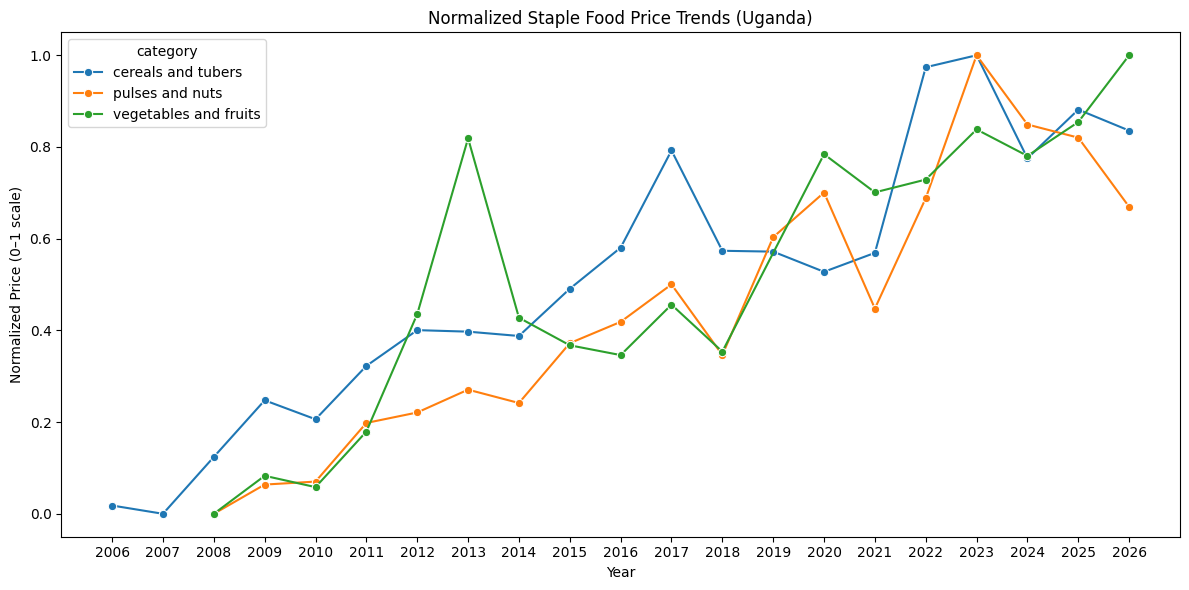

In [29]:
#Normalized plot to understand volatility of these categories
yearly_staple = df_staple.groupby(['year', 'category'])['price'].mean().reset_index()
yearly_staple['normalized_price'] = yearly_staple.groupby('category')['price'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
yearly_staple['pct_change'] = yearly_staple.groupby('category')['price'].pct_change() * 100
volatility = yearly_staple.groupby('category')['pct_change'].std().sort_values(ascending=False)

volatility
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_staple,
    x='year',
    y='normalized_price',
    hue='category',
    marker='o'
)

plt.title('Normalized Staple Food Price Trends (Uganda)')
plt.xlabel('Year')
plt.ylabel('Normalized Price (0–1 scale)')

plt.xticks(yearly_staple['year'].unique())

plt.tight_layout()
plt.show()

- Cereals and tubers; which is mostly beans, are the most consistently rising category , usually leading the other two, further in 2016-2022 where it surged ahead more noticeably. - Pulses and nuts lagged behind for most of the period but caught up sharply around 2023, briefly hitting the maximum normalized value (1.0) before declining again in 2026.
- Vegetables and fruits are the most volatile category, with sharp spikes notably 2013 and dips. It finishes highest of all three in 2026, reaching 1.0.
- Post-2020, all categories accelerate sharply — likely reflecting COVID-19 disruptions, supply chain pressures, and broader global food inflation.
The convergence of all three lines after 2022 suggests system-wide price pressure rather than category-specific issues.

# REGIONAL AND MARKET ANALYSIS

In [30]:
#Regional Average Prices
regional_prices = df_food.groupby('admin1')['price'].mean().sort_values(ascending=False)

regional_prices

,price
admin1,
Kyegegwa,5199.378000
Kiryandongo,4687.374806
Lamwo,4649.888885
Yumbe,4302.940797
Koboko,4003.939452
Moyo,3902.454991
Kabarole,3834.419795
Hoima,3423.489130
Mukono,3406.035714


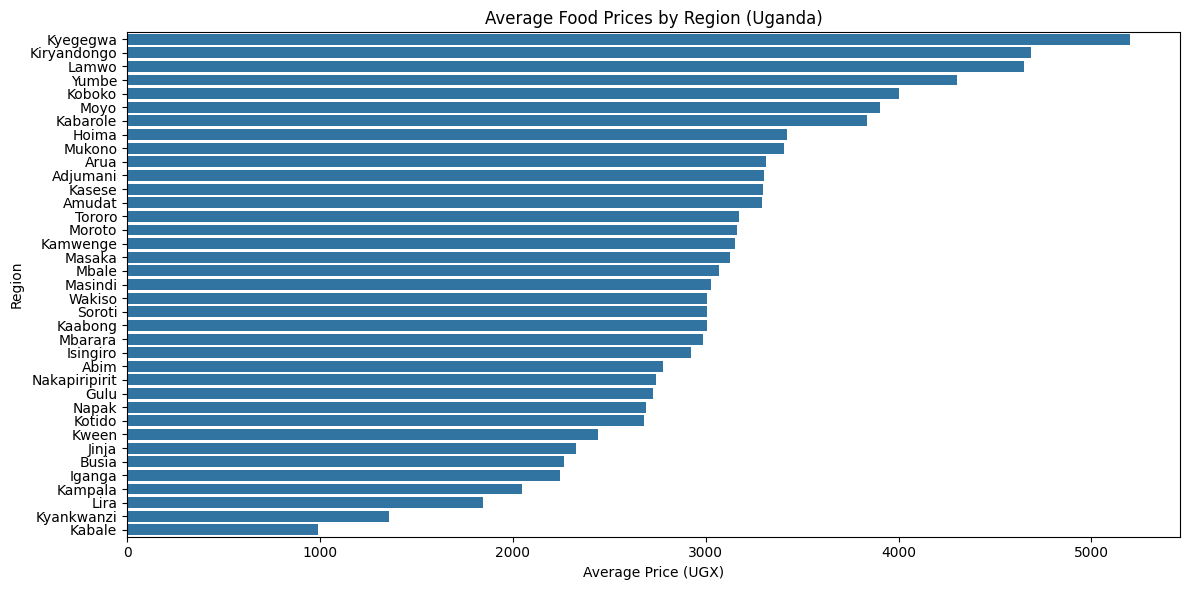

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=regional_prices.values,
    y=regional_prices.index
)

plt.title('Average Food Prices by Region (Uganda)')
plt.xlabel('Average Price (UGX)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

In [32]:
regional_staples = df_food[
    df_food['category'].isin([
        'cereals and tubers',
        'vegetables and fruits',
        'pulses and nuts'
    ])
]

regional_staple_prices = regional_staples.groupby('admin1')['price'].mean().sort_values(ascending=False)

regional_staple_prices

,price
admin1,
Mukono,3100.518868
Kabarole,2965.689516
Masaka,2766.659435
Wakiso,2756.398692
Kasese,2495.798561
Yumbe,2452.570493
Moyo,2433.731606
Kiryandongo,2420.144608
Tororo,2393.926230


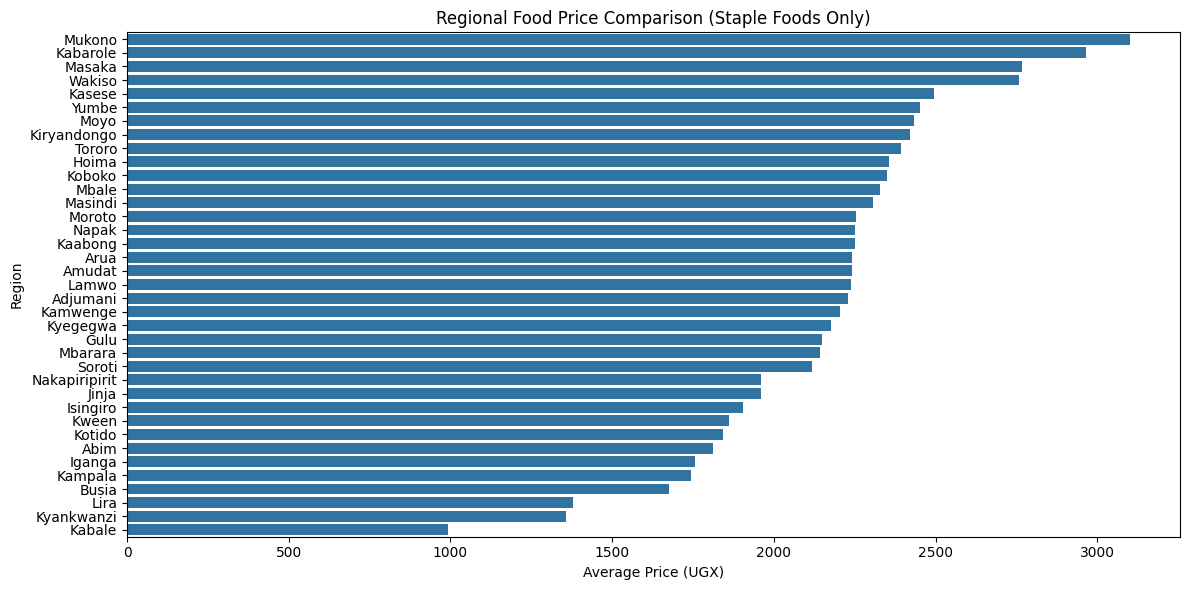

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=regional_staple_prices.values,
    y=regional_staple_prices.index
)

plt.title('Regional Food Price Comparison (Staple Foods Only)')
plt.xlabel('Average Price (UGX)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

From both graphs, we see that as expected, food in more urban areas is generally cheaper and this is probably because of better supply chains, more competition among the markets and easier transport access, which is different from what happens in rural areas.
We also notice that agricultural production areas like Kabale, Lira, Iganga and Busia.
Yumbe is an outlier in that it has  

# STATISTICAL ANALYSIS

# 1. CORRELATION
*Are local food prices influenced by global pricing/currency effects*

In [34]:
commodity_correlation = (
    df_food.groupby('commodity')[['price', 'usdprice']]
    .corr()
    .iloc[0::2, -1]
    .reset_index()
)

commodity_correlation.columns = ['commodity', 'level_1', 'correlation']

commodity_correlation = commodity_correlation.sort_values(
    by='correlation',
    ascending=False
)

commodity_correlation.head(10)

,commodity,level_1,correlation
4,Leafy vegetables,price,0.997856
3,Fish (dry),price,0.997159
1,Cassava (fresh),price,0.997021
8,Milk (fresh),price,0.993217
14,Salt,price,0.988176
10,Millet flour,price,0.986938
11,Oil (vegetable),price,0.984137
15,Sorghum,price,0.980811
12,Plantains,price,0.972046
6,Maize (white),price,0.960251


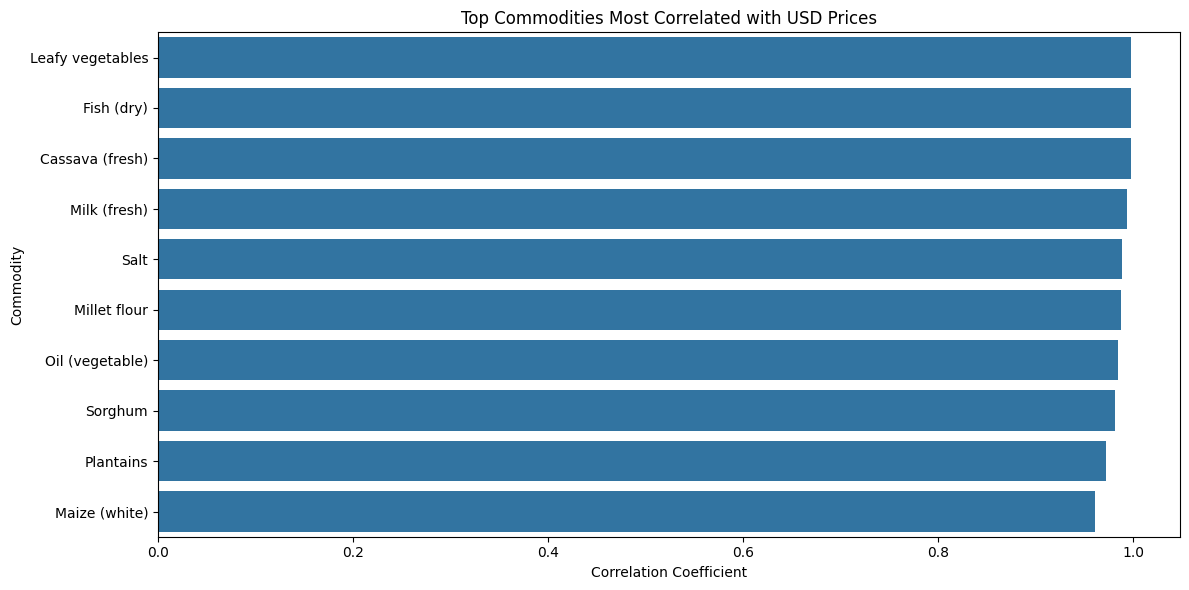

In [35]:
top_corr = commodity_correlation.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_corr,
    x='correlation',
    y='commodity'
)

plt.title('Top Commodities Most Correlated with USD Prices')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Commodity')

plt.tight_layout()
plt.show()

Correlation analysis between UGX prices and USD-denominated prices showed extremely strong positive relationships across nearly all commodities. However, this result is expected because the USD price variable is directly derived from local prices through currency conversion, meaning the two variables are not statistically independent. Therefore, the observed correlations should not be interpreted as evidence that exchange rates drive commodity prices.

# REGRESSION ANALYSIS

In [36]:
import statsmodels.formula.api as smf
model = smf.ols('price ~ year + C(category) + C(admin1)', data=df_food).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     2316.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        08:54:29   Log-Likelihood:            -1.8823e+05
No. Observations:               21649   AIC:                         3.766e+05
Df Residuals:                   21605   BIC:                         3.769e+05
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


The regression model explains approximately 82.2% of the variation in food prices, indicating that temporal, categorical, and regional factors strongly influence commodity pricing patterns in Uganda.
Food prices were found to increase significantly over time, supporting earlier observations of inflationary trends within the dataset. Among food categories, meat, fish, and eggs exhibited the strongest positive association with price levels, followed by oils and fats, suggesting that protein-rich and processed commodities tend to be consistently more expensive.
Regional effects were also significant, with districts such as Mukono, Kyegegwa, and Kabarole showing systematically higher prices even after controlling for category and year effects.
These findings highlight the combined influence of inflation, commodity type, and spatial market dynamics on food affordability across Uganda.